c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jgooh\anaconda3\envs\cs4330\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
       

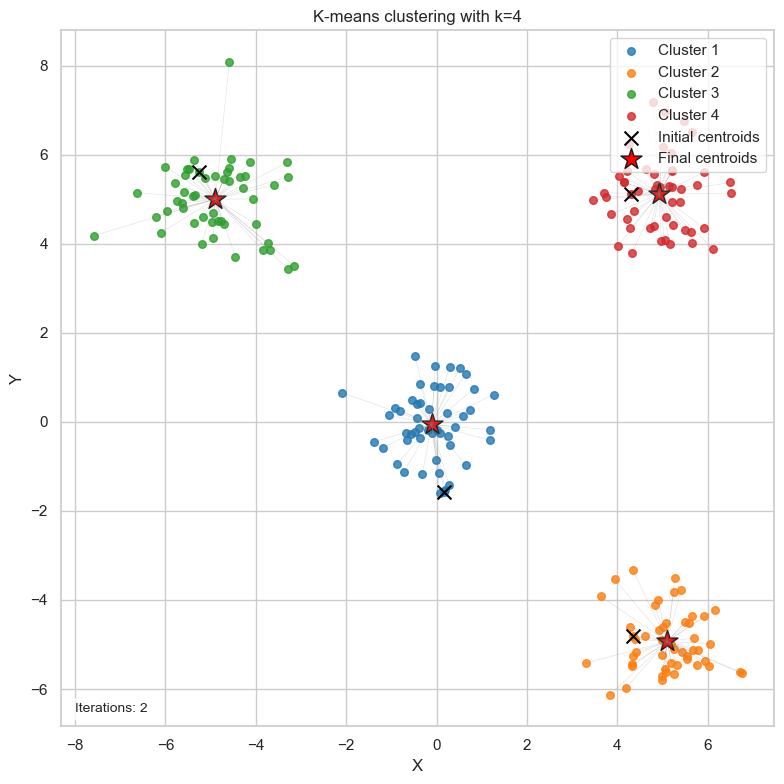

In [2]:
# kmeans_4_plot.py
!pip install seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set(style="whitegrid", context="notebook")

# Generate synthetic data: 4 Gaussian blobs (50 points each)
rng = np.random.RandomState(42)
centers = np.array([[0, 0], [5, 5], [-5, 5], [5, -5]])
std = 0.8
points = []
for c in centers:
    points.append(rng.normal(loc=c, scale=std, size=(50, 2)))
X = np.vstack(points)

# Save initial centroids (random init)
k = 4
init_rng = np.random.RandomState(0)
initial_idx = init_rng.choice(len(X), size=k, replace=False)
initial_centroids = X[initial_idx]

# Run KMeans (scikit-learn) with the same random_state for reproducibility
kmeans = KMeans(n_clusters=k, init=initial_centroids, n_init=1, max_iter=300, random_state=0)
kmeans.fit(X)
labels = kmeans.labels_
final_centroids = kmeans.cluster_centers_
n_iter = kmeans.n_iter_

# Plot
plt.figure(figsize=(8, 8))
palette = sns.color_palette("tab10", n_colors=k)
for i in range(k):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=30, color=palette[i], label=f'Cluster {i+1}', alpha=0.8)

# Draw faint lines from each point to its assigned centroid
for xi, lbl in zip(X, labels):
    cx, cy = final_centroids[lbl]
    plt.plot([xi[0], cx], [xi[1], cy], color='gray', linewidth=0.4, alpha=0.25)

# Initial centroids (black X)
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], marker='x', s=100, color='black', label='Initial centroids')

# Final centroids (red stars)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], marker='*', s=250, color='red', edgecolor='k', label='Final centroids')

plt.title('K-means clustering with k=4')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper right')

# Small text box with iterations
plt.gca().text(0.02, 0.02, f'Iterations: {n_iter}', transform=plt.gca().transAxes, fontsize=10,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Display inline (Jupyter/Colab) and save
plt.show()
# Uncomment to save locally:
# plt.savefig('kmeans_4.png', dpi=300)